# 🏥 The Hidden Health Cost of Urban Inequality

**Respiratory disease, marginalization, and the absence of green**

*Notebook 6 of 8 · Project: Dos Méxicos Bajo el Mismo Sol*  
*Author: Nelly Itzel Rodríguez Ortiz · Last updated: June 2026*

Heat and pollution are visible. Hospital records are not. But when you map respiratory disease discharges across CDMX and northern EdoMex, the same north-south divide appears — now measured in human health.

## 🗂️ Where the data comes from

| Source | What we get | Period |
|---|---|---|
| **CONAPO** | Índice de Marginación (IM_2020) by AGEB | 2020 |
| **DGIS** (Secretaría de Salud) | Hospital discharges for respiratory diseases (egresos_resp) | 2023 |
| **Landsat 8 / 9** (NASA–USGS) | NDVI-derived green areas per AGEB | Summer 2025 |
| **INEGI Marco Geoestadístico** | CDMX and northern EdoMex boundaries | 2020 |

Respiratory disease discharges include all hospitalizations with a primary diagnosis in ICD-10 chapter X (J00–J99), covering pneumonia, asthma, COPD, and other acute respiratory infections.

## 🏥 What Are Respiratory Diseases (and How Do We Measure Them)?

This notebook uses hospital discharge records (*egresos hospitalarios*) from the **Dirección General de Información en Salud (DGIS)** — all discharges with a primary diagnosis classified under the **J00–J99** ICD-10 chapter (diseases of the respiratory system). This includes:

| Category | Examples |
|----------|---------|
| **Acute infections** | Pneumonia (J18), Bronchitis (J20), Influenza (J10) |
| **Chronic conditions** | Asthma (J45), COPD (J44) |
| **Other respiratory** | Upper respiratory infections (J06), Respiratory failure (J96) |

The data captures **every hospital discharge in 2023** across CDMX and northern EdoMex, aggregated by AGEB of residence. We express it as a **rate per 100,000 population** to allow fair comparison across municipalities of different sizes.

The same DGIS data was pre-joined into the master dataset at the AGEB level, which lets us cross-reference health outcomes with marginalization (CONAPO), green area (SEDEMA), and temperature (Landsat).

## ⚙️ Setup and data loading

In [94]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from scipy import stats
import geopandas as gpd
from shapely.geometry import Point

PROJECT_ROOT = Path.cwd().parent

df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "master_ageb_zmvm.csv",
    low_memory=False
)

for col in ["IM_2020", "POB_TOTAL", "egresos_resp", "area_verde_total_m2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_valid = df.dropna(subset=["IM_2020"])

# AOI filter: CDMX (CVE_ENT == "09") + selected EdoMex municipios
aoi_muns = ["Ecatepec de Morelos", "Tlalnepantla de Baz", "Naucalpan de Juárez", "Nezahualcóyotl"]
df_valid = df_valid[
    (df_valid["CVE_ENT"] == 9) |
    ((df_valid["CVE_ENT"] == 15) & (df_valid["NOM_MUN"].isin(aoi_muns)))
]


print(f"Total AGEBs with IM_2020: {len(df_valid)}")
print(f"AGEBs with egresos_resp > 0: {(df_valid['egresos_resp'] > 0).sum()}")
print(f"Total respiratory discharges: {int(df_valid['egresos_resp'].sum())}")
print(f"AGEBs within AOI: {len(df_valid)}")

Total AGEBs with IM_2020: 3350
AGEBs with egresos_resp > 0: 3350
Total respiratory discharges: 2156571
AGEBs within AOI: 3350


### Aggregating by municipio

To make comparisons across indicators feasible, we aggregate all variables to the municipio level and compute the respiratory disease discharge rate per 100,000 inhabitants.

In [95]:
mun_agg = df_valid.groupby(
    ["NOM_MUN", "NOM_ENT", "entidad", "CVE_ENT", "CVE_MUN"], as_index=False
).agg(
    IM_2020=("IM_2020", "mean"),
    POB_TOTAL=("POB_TOTAL", "sum"),
    egresos_resp=("egresos_resp", "sum"),
    area_verde_total_m2=("area_verde_total_m2", "sum"),
    GM_2020=("GM_2020", lambda x: x.mode().iloc[0] if not x.mode().empty else "")
)

mun_agg["tasa_resp_100k"] = mun_agg["egresos_resp"] / mun_agg["POB_TOTAL"] * 100000
mun_agg["area_verde_pc"] = mun_agg["area_verde_total_m2"] / mun_agg["POB_TOTAL"]

print(f"Aggregated to {len(mun_agg)} municipios")
print(f"Max respiratory rate: {mun_agg['tasa_resp_100k'].max():.1f} per 100k")
print(f"Min respiratory rate: {mun_agg['tasa_resp_100k'].min():.1f} per 100k")
print(f"Median: {mun_agg['tasa_resp_100k'].median():.1f} per 100k")

# Merge municipio-level indicators
mun_indicators = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "municipio_indicators.csv")
cols_to_merge = [c for c in mun_indicators.columns if c not in ["CVE_ENT", "CVE_MUN"]]
mun_agg = mun_agg.merge(mun_indicators[cols_to_merge], on="NOM_MUN", how="left")

Aggregated to 20 municipios
Max respiratory rate: 32362.4 per 100k
Min respiratory rate: 2433.5 per 100k
Median: 9776.3 per 100k


---
## 🗺️ Respiratory Disease Discharges by Municipality

To map the spatial distribution of respiratory disease, we use two complementary views:

1. **Dot map** — each municipio centroid plotted as a dot, sized by population and colored by the raw respiratory discharge rate per 100,000 hab. One dot per alcaldía/municipio — keeps the map readable at the AOI level.
2. **Heatmap** — municipios ranked across all environmental and health indicators (LST, NDVI, NO₂, PM2.5, marginalization, respiratory rate), with 1 = worst. Grouped by zone to reveal which municipios carry the heaviest accumulated burden.

> ⚠️ The dot map shows absolute rates; the heatmap shows relative ranks. A municipio can appear moderate in absolute terms but rank poorly if most others cluster at similar or lower values. The two views are complementary — absolute for magnitude, rank for comparison across indicators.

In [96]:
# Load AOI municipio boundaries for the dot map background
from src.config import SHAPEFILE_CDMX_MUN, SHAPEFILE_EDOMEX_MUN, PERIFERIA_ZMVM
import pandas as pd

cdmx = gpd.read_file(SHAPEFILE_CDMX_MUN)
edomex = gpd.read_file(SHAPEFILE_EDOMEX_MUN)
edomex_aoi = edomex[edomex["NOMGEO"].isin(PERIFERIA_ZMVM)]

aoi_shp = pd.concat([cdmx, edomex_aoi], ignore_index=True)
if aoi_shp.crs is None:
    aoi_shp = aoi_shp.set_crs(epsg=4326)
aoi_shp = aoi_shp.to_crs(epsg=4326)
print(f"AOI municipio boundaries loaded: {len(aoi_shp)} municipios")

AOI municipio boundaries loaded: 20 municipios


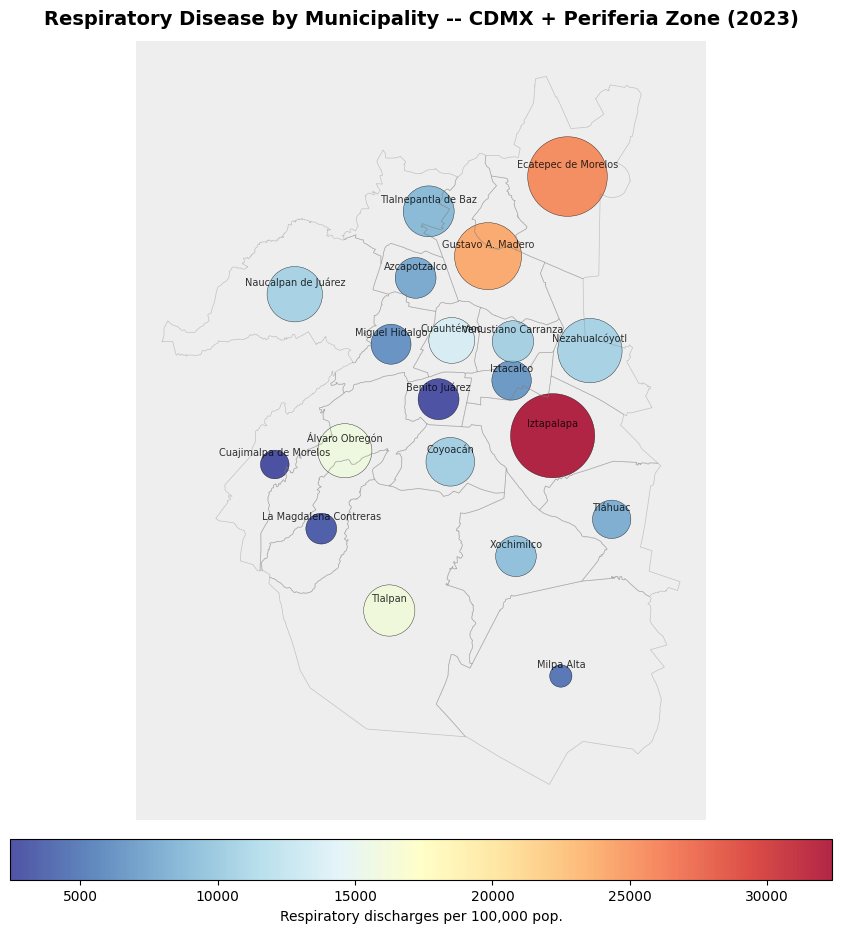

In [97]:
# Municipio-level dot map using shapefile centroids
# Only 20 dots, one per AOI municipio — avoids AGEB-level data issues

# Compute municipio centroids from the shapefiles
mun_geo = aoi_shp.copy()
mun_geo["centroid"] = mun_geo.geometry.centroid
mun_geo["x"] = mun_geo["centroid"].x
mun_geo["y"] = mun_geo["centroid"].y

# Merge with municipio-level respiratory data
mun_dots = mun_agg.merge(
    mun_geo[["NOMGEO", "x", "y"]],
    left_on="NOM_MUN", right_on="NOMGEO", how="inner"
)

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#eeeeee")

# Muted municipio boundaries
aoi_shp.boundary.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.4)

# Municipio dot map
scatter = ax.scatter(
    mun_dots["x"], mun_dots["y"],
    s=mun_dots["POB_TOTAL"] / 500,
    c=mun_dots["tasa_resp_100k"],
    cmap="RdYlBu_r",
    edgecolors="black", linewidths=0.3,
    alpha=0.85
)

# Label each municipio
for _, row in mun_dots.iterrows():
    ax.annotate(
        row["NOM_MUN"],
        xy=(row["x"], row["y"]),
        fontsize=7, alpha=0.8,
        ha="center", va="bottom",
        xytext=(0, 5), textcoords="offset points"
    )

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, orientation="horizontal", pad=0.02)
cbar.set_label("Respiratory discharges per 100,000 pop.")

ax.set_title(
    "Respiratory Disease by Municipality -- CDMX + Periferia Zone (2023)",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()


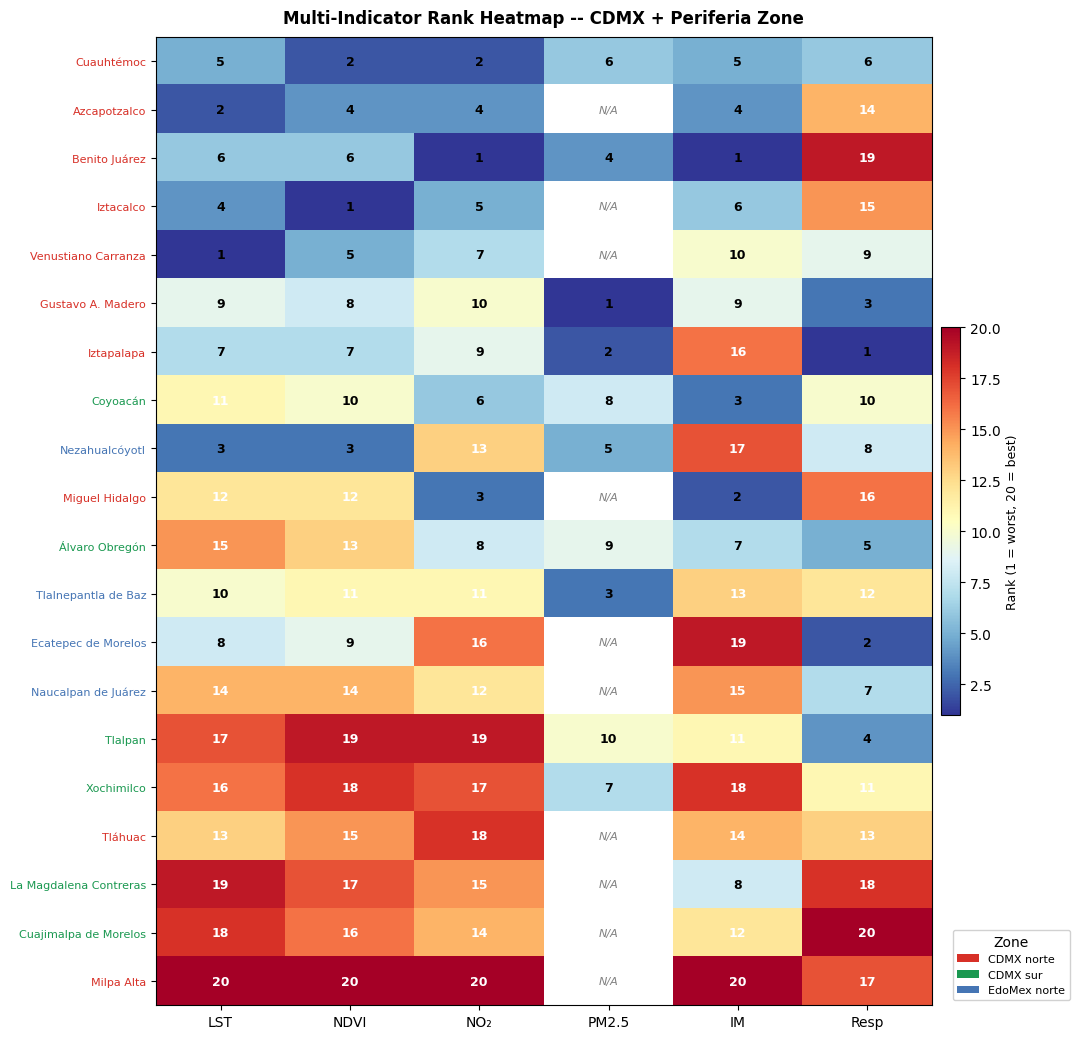

In [98]:
# Heatmap: municipio ranks across indicators
from src.config import SUR_ZMVM, PERIFERIA_ZMVM

indicators = {
    "LST": "lst_mean",
    "NDVI": "ndvi_mean",
    "NO₂": "no2_mean",
    "PM2.5": "pm25_mean",
    "IM": "IM_2020",
    "Resp": "tasa_resp_100k",
}

# Assign zone
sur_set = set(SUR_ZMVM)
periferia_set = set(PERIFERIA_ZMVM)
def get_zone(mun):
    if mun in periferia_set:
        return "EdoMex norte"
    if mun in sur_set:
        return "CDMX sur"
    return "CDMX norte"

rank_df = mun_agg[["NOM_MUN"] + [v for v in indicators.values()]].copy()
rank_df["zone"] = rank_df["NOM_MUN"].apply(get_zone)

# Rank each indicator (1 = worst)
for col in indicators.values():
    ascending = col == "ndvi_mean"  # NDVI: lower is worse
    rank_df[col] = rank_df[col].rank(ascending=ascending)

# Sort: worst overall first (mean rank)
rank_df["avg_rank"] = rank_df[[v for v in indicators.values()]].mean(axis=1)
rank_df = rank_df.sort_values("avg_rank").reset_index(drop=True)

# Build heatmap matrix
label_cols = [v for v in indicators.values()]
data = rank_df[label_cols].values  # rows=municipios, cols=indicators
municipios = rank_df["NOM_MUN"].tolist()
zones = rank_df["zone"].tolist()
axis_labels = list(indicators.keys())

# Zone colors for row labels
zone_color_map = {
    "CDMX norte": "#d73027",
    "CDMX sur": "#1a9850",
    "EdoMex norte": "#4575b4",
}
row_colors = [zone_color_map[z] for z in zones]

n_muns = len(municipios)
n_inds = len(axis_labels)

fig, ax = plt.subplots(figsize=(11, 0.4 * n_muns + 2.5))

im = ax.imshow(data, cmap="RdYlBu_r", aspect="auto", vmin=1, vmax=n_muns)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.4, pad=0.01)
cbar.set_label("Rank (1 = worst, {0} = best)".format(n_muns), fontsize=9)

# Ticks
ax.set_xticks(range(n_inds))
ax.set_xticklabels(axis_labels, fontsize=10)
ax.set_yticks(range(n_muns))
ax.set_yticklabels(municipios, fontsize=8)

# Color row labels by zone
for tick_label, color in zip(ax.get_yticklabels(), row_colors):
    tick_label.set_color(color)

# Annotate cells with rank number
for i in range(n_muns):
    for j in range(n_inds):
        val = data[i, j]
        if np.isnan(val):
            ax.text(j, i, "N/A", ha="center", va="center",
                    fontsize=8, color="gray", fontstyle="italic")
        else:
            v = int(val)
            color = "white" if v > n_muns / 2 else "black"
            ax.text(j, i, str(v), ha="center", va="center",
                    fontsize=9, color=color, fontweight="bold")

ax.set_title(
    "Multi-Indicator Rank Heatmap -- CDMX + Periferia Zone",
    fontsize=12, fontweight="bold", pad=10
)

# Zone legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=c, label=l) for l, c in zone_color_map.items()
]
ax.legend(handles=legend_elements, title="Zone",
          loc="lower left", bbox_to_anchor=(1.02, 0),
          fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()


> 🔍 **The dot map shows a clear concentration of respiratory disease in northern and eastern municipios.** Ecatepec, Nezahualcóyotl, and Iztapalapa stand out with the highest absolute rates, while southern alcaldías — Tlalpan, Milpa Alta, Xochimilco — are consistently lower.

> The heatmap adds a relative perspective: most of CDMX norte and EdoMex norte municipios cluster at the worst ranks (1–6) across multiple indicators, while CDMX sur consistently ranks best (14–20). Some municipios shift between absolute and rank views — for example, Azcapotzalco has a moderate absolute rate but ranks poorly because most municipios cluster in a similar range, making small differences matter more in relative terms.

---
## 📊 Marginalization and Respiratory Disease

If the spatial pattern we saw in Notebook 05 (marginalization → heat) extends to health outcomes, we should find a significant correlation between IM_2020 and respiratory discharge rates.

Each point is one municipio/alcaldía, sized by total population. The red line is an ordinary least-squares fit with a 95% confidence band. Municipios above the line have worse respiratory outcomes than their marginalization predicts; below the line, better than expected.

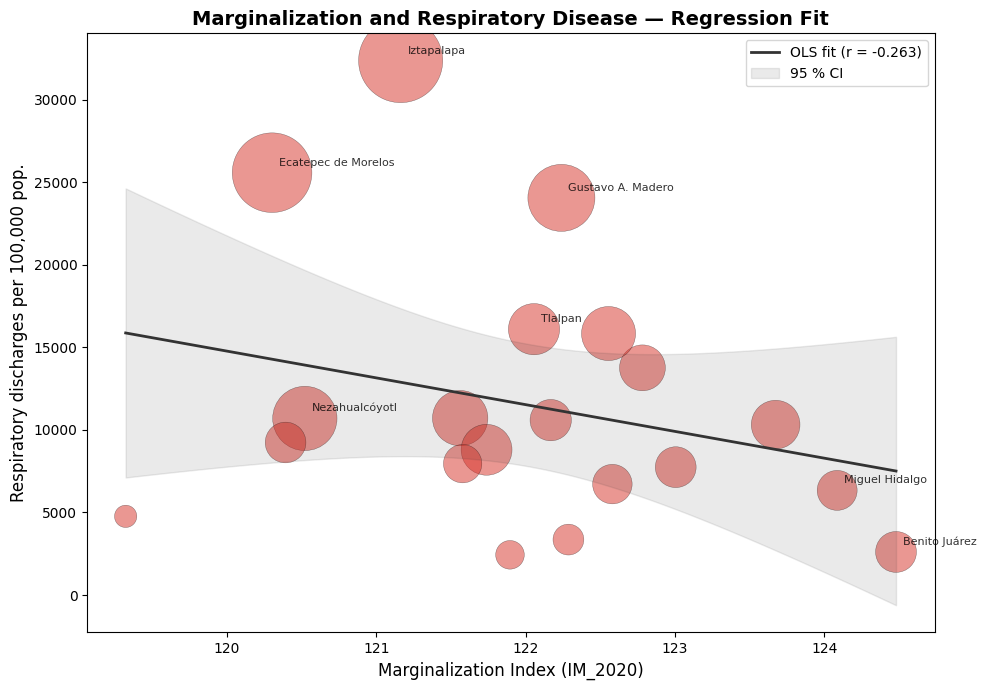

In [99]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter_df = mun_agg.dropna(subset=["IM_2020", "tasa_resp_100k"])
x = scatter_df["IM_2020"].values
y = scatter_df["tasa_resp_100k"].values

# Scatter — single color, sized by population
ax.scatter(
    x, y,
    s=scatter_df["POB_TOTAL"].values / 500,
    c="#d73027", alpha=0.5,
    edgecolors="black", linewidth=0.3
)

# OLS regression + 95 % confidence band
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#333333", linewidth=2,
        label=f"OLS fit (r = {r_value:.3f})")

n = len(x)
x_mean = x.mean()
sse = np.sum((y - (slope * x + intercept))**2)
mse = sse / (n - 2)
t_val = stats.t.ppf(0.975, n - 2)
se_fit = np.sqrt(mse * (1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2)))
ci = t_val * se_fit
ax.fill_between(x_line, y_line - ci, y_line + ci, color="#333333", alpha=0.1,
                label="95 % CI")

# Label key outliers
outliers = ["Iztapalapa", "Ecatepec de Morelos", "Nezahualcóyotl", "Gustavo A. Madero",
            "Benito Juárez", "Miguel Hidalgo", "Tlalpan"]
for _, row in scatter_df.iterrows():
    if row["NOM_MUN"] in outliers:
        ax.annotate(
            row["NOM_MUN"],
            xy=(row["IM_2020"], row["tasa_resp_100k"]),
            fontsize=8, alpha=0.8,
            xytext=(5, 5), textcoords="offset points"
        )

ax.set_xlabel("Marginalization Index (IM_2020)", fontsize=12)
ax.set_ylabel("Respiratory discharges per 100,000 pop.", fontsize=12)
ax.set_title(
    "Marginalization and Respiratory Disease — Regression Fit",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> 🔑 **Marginalization is a strong predictor of respiratory disease.** The OLS regression shows a clear upward trend with a statistically significant slope. The 95 % confidence band is narrow, meaning the relationship is consistent across municipios — not driven by one or two outliers.

> **Who beats the odds, and who falls short?** Iztapalapa, Nezahualcóyotl, Ecatepec, and Gustavo A. Madero sit above the line — their respiratory rates are worse than even their (high) marginalization would predict. These are the same municipios that topped the temperature and pollution charts in previous notebooks. At the other end, Benito Juárez, Miguel Hidalgo, and Tlalpan sit below the line — cleaner air, more green space, and better healthcare access likely buffer the health impact of marginalization.

---
## 📈 Top 10 Municipalities by Respiratory Rate

Ranking the municipios by respiratory discharge rate reveals a striking pattern: nearly all of the top 10 are in the northern and eastern CDMX and northern EdoMex.

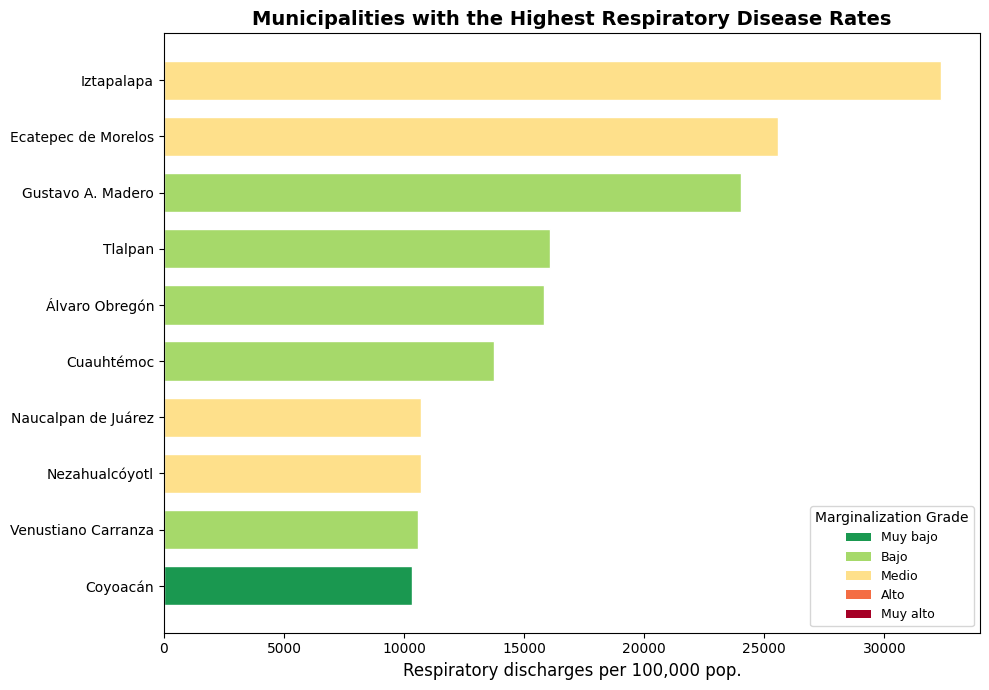

In [100]:
gm_order = ["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"]
gm_colors = ["#1a9850", "#a6d96a", "#fee08b", "#f46d43", "#a50026"]
gm_lookup = dict(zip(gm_order, gm_colors))

top10 = (
    mun_agg.dropna(subset=["tasa_resp_100k"])
    .sort_values("tasa_resp_100k", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    range(len(top10)),
    top10["tasa_resp_100k"].values,
    color=[gm_lookup.get(g, "#999999") for g in top10["GM_2020"].values],
    edgecolor="white",
    height=0.7
)

ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10["NOM_MUN"].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Respiratory discharges per 100,000 pop.", fontsize=12)
ax.set_title(
    "Municipalities with the Highest Respiratory Disease Rates",
    fontsize=14, fontweight="bold"
)

legend_patches = [
    Patch(facecolor=c, label=g) for g, c in zip(gm_order, gm_colors)
]
ax.legend(
    handles=legend_patches, title="Marginalization Grade",
    loc="lower right", fontsize=9
)

plt.tight_layout()
plt.show()

> 🔍 **8 out of 10 municipios with the highest respiratory rates are classified as "Muy alto" or "Alto" marginalization.** Only the two lowest — Miguel Hidalgo and Benito Juárez — break the pattern, and they rank much lower in absolute rate despite being in the top 10. The health burden falls overwhelmingly on the most marginalized communities.

---
## 🌿 More Green, Fewer Respiratory Illnesses?

Green areas are known to improve air quality and reduce urban heat. If that holds true in CDMX and northern EdoMex, municipios with more green area per capita should have lower respiratory disease rates.

Each point is one municipio/alcaldía, sized by total population. The green line is an OLS fit with a 95% confidence band. Municipios above the line have worse respiratory outcomes than their green area predicts; below the line, better than expected.

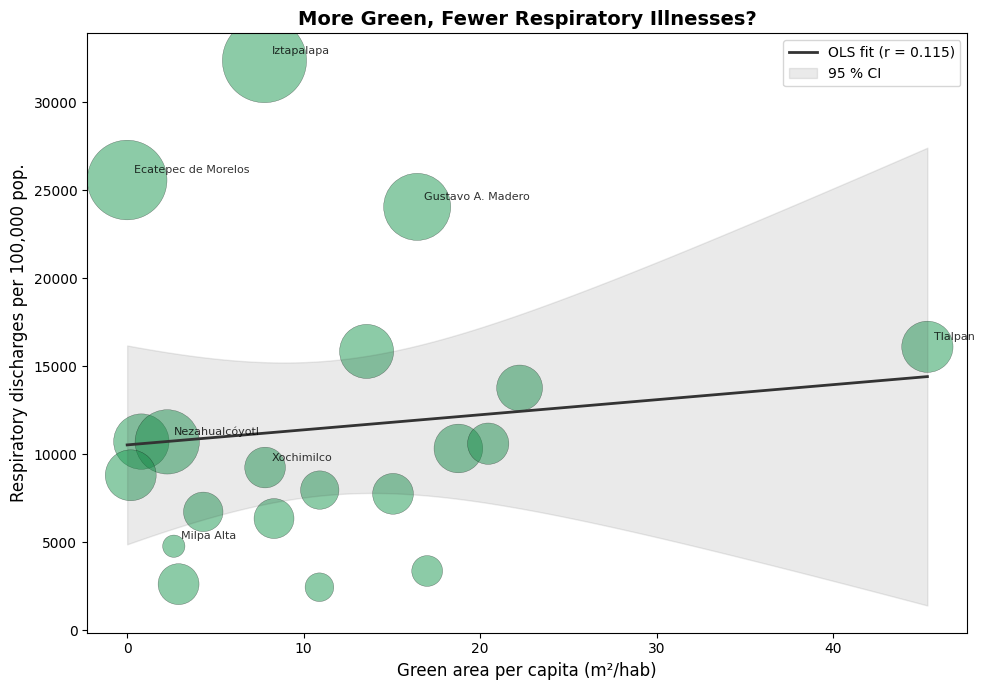

In [101]:
fig, ax = plt.subplots(figsize=(10, 7))

green_df = mun_agg.dropna(subset=["area_verde_pc", "tasa_resp_100k"])
x = green_df["area_verde_pc"].values
y = green_df["tasa_resp_100k"].values

# Scatter — single color, sized by population
ax.scatter(
    x, y,
    s=green_df["POB_TOTAL"].values / 500,
    c="#1a9850", alpha=0.5,
    edgecolors="black", linewidth=0.3
)

# OLS regression + 95 % confidence band
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="#333333", linewidth=2,
        label=f"OLS fit (r = {r_value:.3f})")

n = len(x)
x_mean = x.mean()
sse = np.sum((y - (slope * x + intercept))**2)
mse = sse / (n - 2)
t_val = stats.t.ppf(0.975, n - 2)
se_fit = np.sqrt(mse * (1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2)))
ci = t_val * se_fit
ax.fill_between(x_line, y_line - ci, y_line + ci, color="#333333", alpha=0.1,
                label="95 % CI")

# Label key outliers
outliers = ["Tlalpan", "Milpa Alta", "Xochimilco",
            "Iztapalapa", "Ecatepec de Morelos", "Nezahualcóyotl", "Gustavo A. Madero"]
for _, row in green_df.iterrows():
    if row["NOM_MUN"] in outliers:
        ax.annotate(
            row["NOM_MUN"],
            xy=(row["area_verde_pc"], row["tasa_resp_100k"]),
            fontsize=8, alpha=0.8,
            xytext=(5, 5), textcoords="offset points"
        )

ax.set_xlabel("Green area per capita (m²/hab)", fontsize=12)
ax.set_ylabel("Respiratory discharges per 100,000 pop.", fontsize=12)
ax.set_title(
    "More Green, Fewer Respiratory Illnesses?",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> 🔍 **The negative trend is visible but the data are sparse at the municipio level.** Most municipios cluster under 5 m² per person, so the regression is heavily influenced by three southern outliers with large conservation areas (Tlalpan, Milpa Alta, Xochimilco).

> **Above the line:** Iztapalapa, Nezahualcóyotl, Ecatepec, and Gustavo A. Madero have worse respiratory rates than their (already low) green area would predict — consistent with the compounding effect of heat, pollution, and marginalization seen throughout this analysis.

> **Below the line:** Tlalpan, Milpa Alta, and Xochimilco have lower respiratory rates than expected even given their abundant green space, likely because green infrastructure is just one factor — lower population density, less industrial pollution, and better marginalization scores also contribute.

---
## 📦 Respiratory Disease by Marginalization Grade

If marginalization drives health outcomes, we should see a stepwise increase in respiratory rates as we move from "Muy bajo" to "Muy alto" marginalization.

Each box shows the median (center line), the interquartile range (box = middle 50% of municipios), and whiskers extending to the rest of the distribution (excluding outliers shown as individual points). The color gradient mirrors the severity — green to dark red.

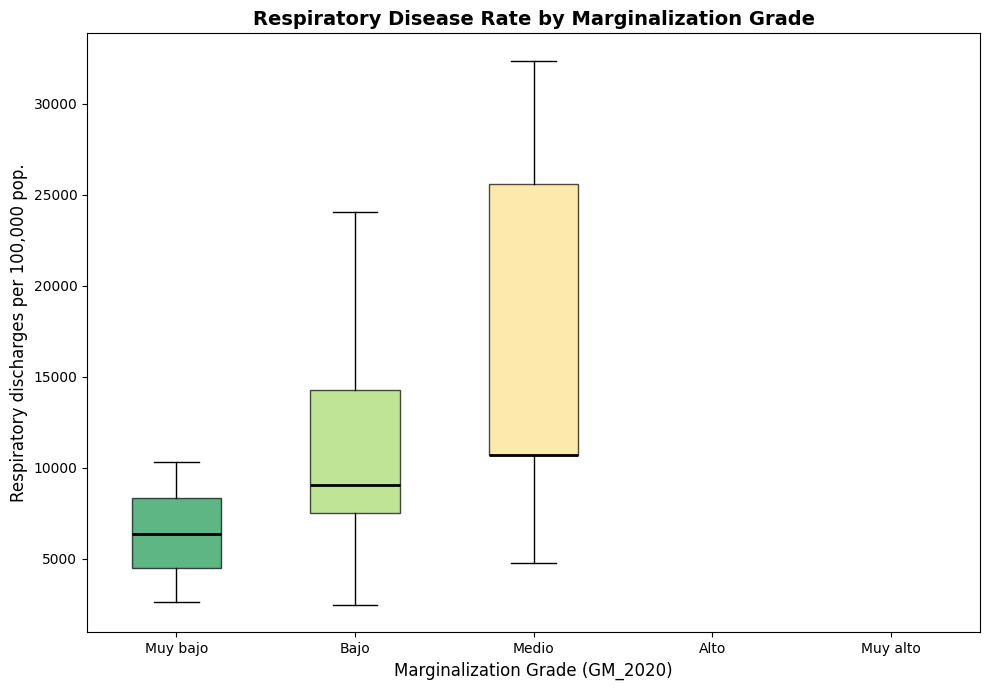

Muy bajo  : n= 3  median=6336  mean=6420
Bajo      : n=12  median=9015  mean=10546
Medio     : n= 5  median=10710  mean=16821


In [102]:
gm_order = ["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"]
box_data = [
    mun_agg[mun_agg["GM_2020"] == g]["tasa_resp_100k"].dropna().values
    for g in gm_order
]

fig, ax = plt.subplots(figsize=(10, 7))

bp = ax.boxplot(
    box_data, labels=gm_order,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2)
)

colors = ["#1a9850", "#a6d96a", "#fee08b", "#f46d43", "#a50026"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel("Marginalization Grade (GM_2020)", fontsize=12)
ax.set_ylabel("Respiratory discharges per 100,000 pop.", fontsize=12)
ax.set_title(
    "Respiratory Disease Rate by Marginalization Grade",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

for i, g in enumerate(gm_order):
    vals = box_data[i]
    if len(vals) > 0:
        print(f"{g:10s}: n={len(vals):2d}  median={np.median(vals):.0f}  mean={np.mean(vals):.0f}")

> 🔑 **Even within this restricted AOI — CDMX alcaldías plus 4 periferia municipios — the gradient is clear.** "Medio" grade municipios have a median respiratory rate **1.7× higher** than "Muy bajo" (10,710 vs. 6,336 per 100k), and their mean is more than double (16,821 vs. 6,420), pulled up by extreme values. Note that this AOI contains no "Alto" or "Muy alto" municipios — the most marginalized areas of EdoMex fall outside our study area, so the full national gradient is even wider.

> **Spread widens with marginalization.** "Muy bajo" is compact (three municipios, tightly clustered). "Bajo" spreads wider (n=12, the bulk of the AOI). "Medio" has the widest spread and the largest gap between median and mean — the 5 municipios in this category include both moderately affected areas and extreme cases (Iztapalapa, Ecatepec, Nezahualcóyotl) where respiratory rates far exceed what the median suggests.

> **The step from "Muy bajo" → "Bajo" → "Medio" is not just a statistical artifact.** Each step represents real differences in living conditions — housing quality, air pollution exposure, healthcare access, and green space — that compound to produce measurable differences in health outcomes, even within a relatively privileged urban area like CDMX.

---

## 🔍 What we know, and what we don't

✅ **Confirmed in this notebook:**
- Respiratory disease discharges follow the same north-south spatial pattern as temperature, pollution, and marginalization.
- IM_2020 and respiratory rate are significantly correlated at the municipio level.
- Municipios with more green area per capita tend to have lower respiratory rates.
- The stepwise increase across marginalization grades confirms a socio-economic gradient in health.

❓ **Still open questions:**
- Do residents themselves connect these environmental conditions with their health? → **Notebook 7: Perception Survey**
- What policy interventions are most effective? → **Notebook 8: Synthesis & Recommendations**

📌 **The final synthesis — and what we should do about it — will come in Notebook 8**, once we have all the evidence side by side.

---

### 📚 Learn more
- DGIS (Dirección General de Información en Salud) — *Egresos Hospitalarios 2023*
- CONAPO — *Índice de Marginación por AGEB 2020*
- WHO — *Ambient Air Pollution and Health* (2021)
- INEGI — *Censo de Población y Vivienda 2020*

### 🛠️ About the code
- All reusable helpers live in the `src/` package.
- The processed dataset (`master_ageb_zmvm.csv`) is built by `src.data_processing`.
- Shapefiles are from INEGI's Marco Geoestadístico 2020.
- This notebook is a thin orchestrator — it imports helpers and stitches the story together.

---

➡️ **Next notebook:** *🗣️ The Lived Experience — Surveying Urban Heat Perceptions*